In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.utils import Utils
from stericheight.load_meop import MEOP
from region import Region
from functions import Functions
from OceanDataStore import OceanDataCatalog

pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
import xesmf as xe
import glob

refz=1000
fname_glorys1 = '../data/GLORYS/glorys_001.nc'
fname_glorys2 = '../data/GLORYS/glorys_002.nc'
fname_sose = '../data/SOSE/adelie3d/Jenny_AdelieSlices'

In [4]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [5]:
full_extent = [138, 150,-68,-64]
expanded_extent = [132, 156, -68, -62]

elevation = elevation_.sel(latitude = slice(expanded_extent[2], expanded_extent[3]), longitude = slice(expanded_extent[0],expanded_extent[1]))


In [6]:
# GET COLOURS
cdict = pickle.load(open('cdict.pkl','rb'))


In [7]:
def gph(ds_rho):# calculate specific volume for each profile/level
    vs = (1/ds_rho - 1/gsw.density.rho(35,0,refz))/9.82
    vs = vs.assign_coords({'PRES_Pa': ds_rho.pres*10000})

    # integrate vs to get gpha for each profile
    # TODO deal with NaNs
    vs.load()
    return vs.groupby('time').map(lambda x: fns.integrate_na(x))

In [8]:
sose = xr.open_dataset('spatial_average_sose.nc')
en4 = xr.open_dataset('spatial_average_en4.nc')
glorys = xr.open_dataset('spatial_average_glorys.nc')
nemo = xr.open_dataset('spatial_average_nemo.nc')

In [9]:
# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]

In [10]:
dotds = DOT(ver='egm').ds.rename({'ug':'u10','vg':'v10'})
lwe_ds = GRACE(from_file=True).ds

dot = fns.crop_to_extent(dotds.dot,extent)
lwe = fns.crop_to_extent(lwe_ds.lwe_thickness,extent)

sha_ds_sla = StericHeight(ssh_ref='DOT',
                          ssh=dot,
                          msl=None,
                          lwe=lwe,
                          ).get_sha()

sha = sha_ds_sla.sha

sha = sha.where(sha < 20,np.nan)

In [107]:
sha_ds_sla

<xarray.Dataset> Size: 3MB
Dimensions:    (longitude: 16, latitude: 12, time: 270)
Coordinates:
  * longitude  (longitude) float64 128B 137.5 138.5 139.5 ... 150.5 151.5 152.5
  * latitude   (latitude) float64 96B -68.75 -68.25 -67.75 ... -63.75 -63.25
  * time       (time) datetime64[ns] 2kB 2002-07-01 2002-08-01 ... 2024-12-01
Data variables:
    ssh        (time, latitude, longitude) float64 415kB nan nan ... -199.3
    lwe        (time, latitude, longitude) float64 415kB nan nan ... 3.797 4.653
    msl        (time, latitude, longitude) float64 415kB nan nan nan ... nan nan
    msla       (time, latitude, longitude) float64 415kB nan nan nan ... nan nan
    ssha       (time, latitude, longitude) float64 415kB nan nan ... 1.507 1.334
    eha        (time, latitude, longitude) float64 415kB nan nan ... 2.183 2.852
    sha        (time, latitude, longitude) float64 415kB nan nan ... -1.497
    shaa       (time, latitude, longitude) float64 415kB nan nan ... -0.6235
    elevation  (latitude, longitude) float64 2kB nan nan ... -3.454e+03

In [31]:
sose=xr.open_mfdataset(glob.glob(fname_sose + '/*.nc'))

idx=sose.SALT.load() > 5
sose = sose.where(idx,np.nan)

# use SOSE data to define time and loc bounds
extent = [sose.XC.min(), sose.XC.max(), sose.YC.min(), sose.YC.max()]

sose['pres'] = gsw.conversions.p_from_z(sose.Z,sose.YC.mean())

sose = sose.swap_dims({'Z':'pres'}).drop_vars('Z')

# make monthly
sose=sose.resample({'time':'MS'}).mean()

sose = sose.sel(pres=slice(0,1000))
sose['asal'] = gsw.SA_from_SP(sose.SALT,sose.pres,sose.XC,sose.YC)
sose['ctemp'] = gsw.CT_from_pt(sose.asal,sose.THETA)
sose['rho'] = gsw.density.rho(sose.asal,sose.ctemp,sose.pres)

sose['gph'] = gph(sose.rho)

sose.to_netcdf('spatial_average_sose.nc')

In [33]:
en4 = xr.open_dataset('en4_analysis.nc')
en4 = fns.crop_to_extent(en4,extent)

# sort time
en4 = en4.resample({'time':'MS'}).mean()
en4['month'] = en4.time.dt.month
en4['year'] = en4.time.dt.year

en4['pres'] = gsw.conversions.p_from_z(-en4.depth,en4.lat.mean())

en4 = en4.swap_dims({'depth':'pres'}).drop_vars('depth')

en4 = en4.sel(pres=slice(0,1000))

en4['asal'] = gsw.SA_from_SP(en4.salinity,en4.pres,en4.lon,en4.lat)
en4['ctemp'] = gsw.CT_from_pt(en4.asal,en4.temperature-273.15)
en4['rho'] = gsw.density.rho(en4.asal,en4.ctemp,en4.pres)

en4['gph'] = gph(en4.rho)

en4.to_netcdf('spatial_average_en4.nc')

/tmp/ipykernel_1855903/3993211432.py:21: UserWarning: Variable time has datetime type and a bounds variable but time.encoding does not have units specified. The units encodings for time and time_bnds will be determined independently and may not be equal, counter to CF-conventions. If this is a concern, specify a units encoding for time before writing to a file.
  en4.to_netcdf('spatial_average_en4.nc')


In [11]:
# define time bounds covering both datasets
t1 = sose.time[0]
t2 = glorys.time[-1]


In [12]:
ds1 = xr.open_dataset(fname_glorys1)
ds2 = xr.open_dataset(fname_glorys2)
glorys = xr.merge([ds1,ds2])

glorys = fns.crop_to_extent(glorys,extent).coarsen({'latitude':6,'longitude':6}).mean()
# make monthly
glorys = glorys.resample({'time':'MS'}).mean()
glorys['pres'] = gsw.conversions.p_from_z(-glorys.depth,glorys.latitude.mean())

glorys = glorys.swap_dims({'depth':'pres'}).drop_vars('depth').sel(pres=slice(0,1000))

glorys['asal'] = gsw.SA_from_SP(glorys.so,glorys.pres,glorys.longitude,glorys.latitude)
glorys['ctemp'] = gsw.CT_from_pt(glorys.asal,glorys.thetao)
glorys['rho'] = gsw.density.rho(glorys.asal,glorys.ctemp,glorys.pres)

glorys['gph'] = gph(glorys.rho)

glorys.to_netcdf('spatial_average_glorys.nc')

/tmp/ipykernel_3510125/1302765732.py:3: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  glorys = xr.merge([ds1,ds2])


In [ ]:
# load nemo data
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_4d',variable_names=['thetao_con','so_abs'])

# prepare nemo
# crop to region
lats = nemo.nav_lat.load()
lons = nemo.nav_lon.load()
mask = (lats >= extent[2]) & (lats <= extent[3]) & (lons >= extent[0]) & (lons <= extent[1])
# crop to area and coarsen
nemo = nemo.where(mask,drop=True).coarsen({'y':6,'x':6},boundary='trim').mean()

# make monthly
nemo = nemo.rename({'time_counter':'time'}).resample({'time':'MS'}).mean()

nemo['pres'] = gsw.conversions.p_from_z(-nemo.deptht,nemo.nav_lat.mean())

nemo = nemo.swap_dims({'deptht':'pres'}).drop_vars('deptht').sel(pres=slice(0,1000))

nemo['rho'] = gsw.density.rho(nemo.so_abs,nemo.thetao_con,nemo.pres)

nemo['gph'] = gph(nemo.rho)

nemo.to_netcdf('spatial_average_nemo.nc')

  2026-04-28T05:21:17.057447Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



In [12]:
t1 = sose.time[0]
t2 = glorys.time[-1]

In [13]:
# recompute gpha wrt time period
sha_ds_sla['shaa'] = sha - sha.sel(time=slice(t1,t2)).mean()
sose['gpha'] = sose.gph - sose.gph.sel(time=slice(t1,t2)).mean()
en4['gpha'] = en4.gph - en4.gph.sel(time=slice(t1,t2)).mean()
glorys['gpha'] = glorys.gph - glorys.gph.sel(time=slice(t1,t2)).mean()
nemo['gpha'] = nemo.gph - nemo.gph.sel(time=slice(t1,t2)).mean()


In [14]:
# compute spatial averages on the shelf
sha_ds_sla['elevation'] = elevation.interp(latitude=sha_ds_sla.latitude,longitude=sha_ds_sla.longitude)
nemo['elevation'] = elevation.interp(latitude=nemo.nav_lat,longitude=nemo.nav_lon)
glorys['elevation'] = elevation.interp(latitude=glorys.latitude,longitude=glorys.longitude)
en4['elevation'] = elevation.interp(latitude=en4.lat,longitude=en4.lon)
sose['elevation'] = elevation.interp(latitude=sose.YC,longitude=sose.XC)

In [15]:
shelf_sha = sha_ds_sla.shaa.where(sha_ds_sla.elevation > -1000,drop=True)
shelf_gph_en4 = en4.gpha.where(en4.elevation > -1000, drop=True)
shelf_gph_sose = sose.gpha.where(sose.elevation > -1000, drop=True)
shelf_gph_glorys= glorys.gpha.where(glorys.elevation > -1000, drop=True)
shelf_gph_nemo = nemo.gpha.where(nemo.elevation > -1000,drop=True)
shelf_mass = sha_ds_sla.eha.where(sha_ds_sla.elevation > -1000,drop=True)

In [16]:
shelf_gph_nemo = shelf_gph_nemo.sel(time=slice(sha.time[0],sha.time[-1]))

In [17]:
shelf_sha_tmean = shelf_sha.mean(['latitude','longitude'])
shelf_gph_en4_tmean = shelf_gph_en4.mean(['lat','lon'])
shelf_gph_sose_tmean = shelf_gph_sose.mean(['XC','YC'])
shelf_mass_tmean = shelf_mass.mean(['latitude','longitude'])
shelf_gph_glorys_tmean = shelf_gph_glorys.mean(['latitude','longitude'])
shelf_gph_nemo_tmean = shelf_gph_nemo.mean(['x','y'])


In [18]:
# assign colours for easy plotting
colors = {'SHA': 'rebeccapurple',
          'GPHA': 'lightsteelblue',
          'GLORYS': 'lightseagreen',
          'NEMO' : 'palevioletred',
          'SOSE' : 'orange',
          'EN4': 'dodgerblue',
          'MASS': 'grey'}


In [19]:

month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
month_values = xr.DataArray(np.arange(1,13),coords={'month':np.arange(1,13)})

def plotvar(ax,da,label,ls='-',roll=False):
    da_ = da.rolling({'time':3}).mean() if roll else da

    ax.plot(da_.time,da_,label=label,c=colors[label],ls=ls)

def plotcli(ax,da,label,ls='-'):
    ax.plot(month_values,da,label=label,c=colors[label],ls=ls)
    ax.set_xticks(np.arange(1,13),labels=month_labels)

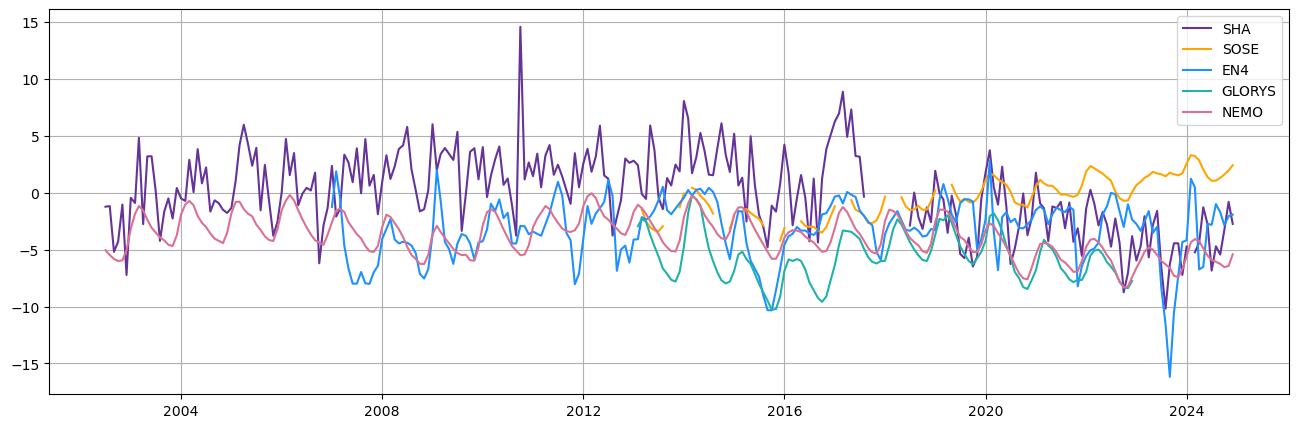

In [20]:
fig, ax = plt.subplots(figsize=(16,5))
plotvar(ax,shelf_sha_tmean,'SHA')
plotvar(ax,shelf_gph_sose_tmean,'SOSE')
plotvar(ax,shelf_gph_en4_tmean,label='EN4')
plotvar(ax,shelf_gph_glorys_tmean,label='GLORYS')
plotvar(ax,shelf_gph_nemo_tmean,label='NEMO')
ax.legend()
ax.grid()

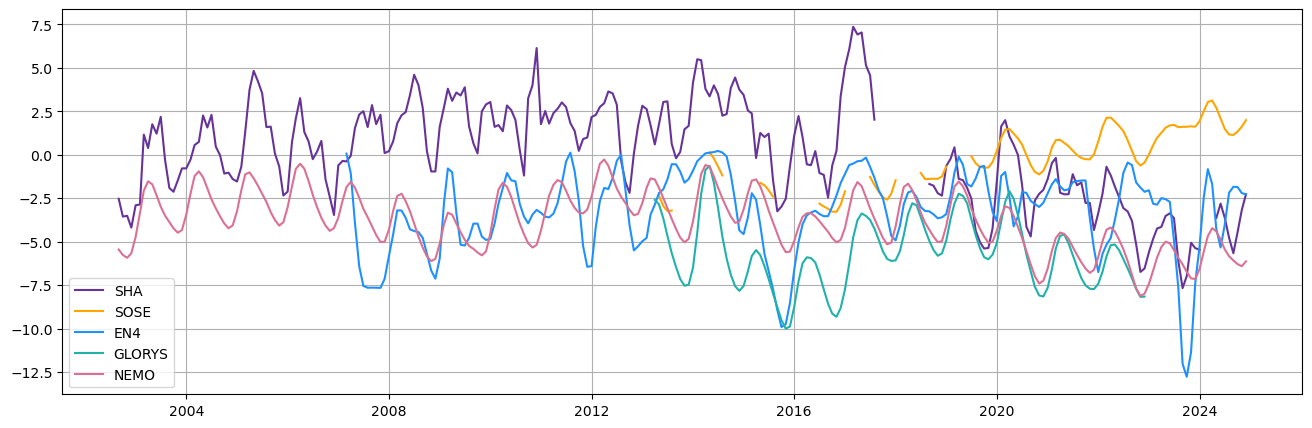

In [ ]:
fig, ax = plt.subplots(figsize=(16,5))
plotvar(ax,shelf_sha_tmean,'SHA',roll=True)
plotvar(ax,shelf_gph_sose_tmean,'SOSE',roll=True)
plotvar(ax,shelf_gph_en4_tmean,label='EN4',roll=True)
plotvar(ax,shelf_gph_glorys_tmean,label='GLORYS',roll=True)
plotvar(ax,shelf_gph_nemo_tmean,label='NEMO',roll=True)
ax.legend()
ax.grid()

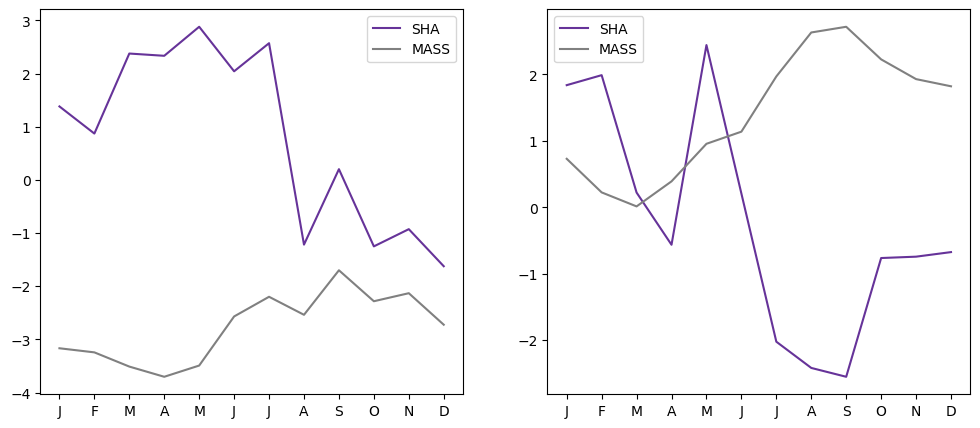

In [46]:
sha_pre2010 = shelf_sha_tmean.sel(time=slice(shelf_sha_tmean.time[0],pd.Timestamp(2010,2,10)))
lwe_pre2010 = shelf_mass_tmean.sel(time=slice(shelf_mass_tmean.time[0],pd.Timestamp(2010,2,10)))

sha_pos2010 = shelf_sha_tmean.sel(time=slice(pd.Timestamp(2010,3,1),shelf_sha_tmean.time[-1]))
lwe_pos2010 = shelf_mass_tmean.sel(time=slice(pd.Timestamp(2010,3,1),shelf_mass_tmean.time[-1]))

fig,ax = plt.subplots(1,2,figsize=(12,5))
plotcli(ax[0],sha_pre2010.groupby('time.month').mean(),'SHA')
plotcli(ax[0],lwe_pre2010.groupby('time.month').mean(), 'MASS')
plotcli(ax[1],sha_pos2010.groupby('time.month').mean(),'SHA')
plotcli(ax[1],lwe_pos2010.groupby('time.month').mean(), 'MASS')
[ax.legend() for ax in ax]
# plotcli(ax[0],sha_pre2010.groupby('time.month') - sha_pre2010.groupby('time.month').mean(),'SHA')
# plotcli(ax[0],lwe_pre2010.groupby('time.month') - lwe_pre2010.groupby('time.month').mean(), 'MASS')
# plotcli(ax[1],sha_pos2010.groupby('time.month') - sha_pos2010.groupby('time.month').mean(),'SHA')
# plotcli(ax[1],lwe_pos2010.groupby('time.month') - lwe_pos2010.groupby('time.month').mean(), 'MASS')

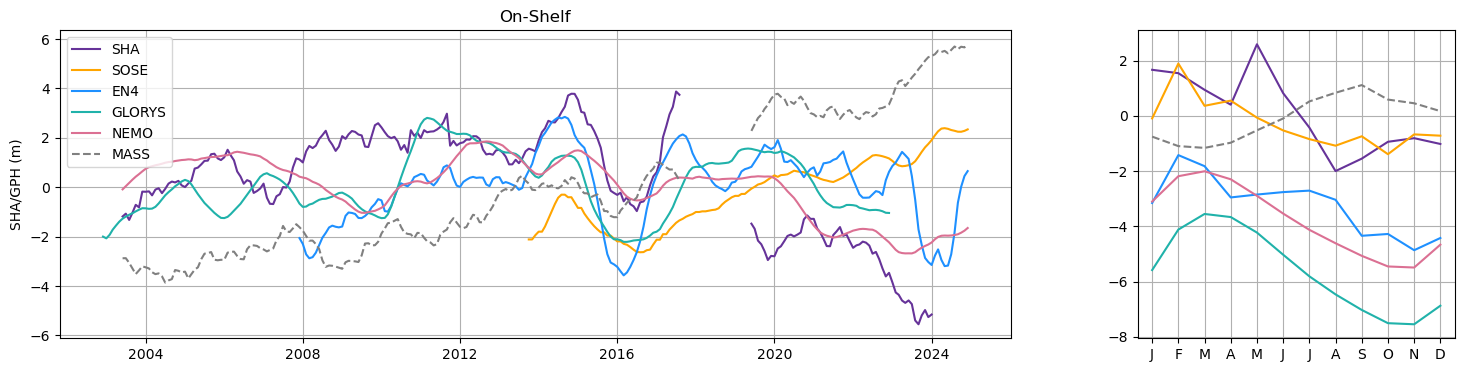

In [114]:
shelf_sha_clim = shelf_sha_tmean.groupby('time.month').mean()
shelf_gph_sose_clim = shelf_gph_sose_tmean.groupby('time.month').mean()
shelf_gph_en4_clim = shelf_gph_en4_tmean.groupby('time.month').mean()
shelf_gph_glorys_clim = shelf_gph_glorys_tmean.groupby('time.month').mean()
shelf_gph_nemo_clim = shelf_gph_nemo_tmean.groupby('time.month').mean()
shelf_mass_clim = shelf_mass_tmean.groupby('time.month').mean()


fig, axs = plt.subplots(1,2,figsize=(18,4),width_ratios=[3,1])
ax=axs[0]
plotvar(ax,(shelf_sha_tmean.groupby('time.month') - shelf_sha_clim).rolling({'time':12}).mean(),label='SHA')
plotvar(ax,(shelf_gph_sose_tmean.groupby('time.month') - shelf_gph_sose_clim).rolling({'time':12},min_periods=8).mean(),label='SOSE')
plotvar(ax,(shelf_gph_en4_tmean.groupby('time.month') - shelf_gph_en4_clim).rolling({'time':12}).mean(),label='EN4')
plotvar(ax,(shelf_gph_glorys_tmean.groupby('time.month') - shelf_gph_glorys_clim).rolling({'time':12}).mean(),label='GLORYS')
plotvar(ax,(shelf_gph_nemo_tmean.groupby('time.month') - shelf_gph_nemo_clim).rolling({'time':12}).mean(),label='NEMO')
plotvar(ax,(shelf_mass_tmean.groupby('time.month') - shelf_mass_clim).rolling({'time':12}).mean(),label='MASS',ls='--')

ax.legend()
ax.grid()
ax.set_ylabel('SHA/GPH (m)')
ax.set_title('On-Shelf')

ax=axs[1]
plotcli(ax,shelf_sha_clim,label='SHA')
plotcli(ax,shelf_gph_sose_clim,label='SOSE')
plotcli(ax,shelf_gph_en4_clim,label='EN4')
plotcli(ax,shelf_gph_glorys_clim,label='GLORYS')
plotcli(ax,shelf_gph_nemo_clim,label='NEMO')
plotcli(ax,shelf_mass_clim,label='MASS',ls='--')

ax.grid()

In [81]:
offshelf_sha = sha_ds_sla.shaa.where(sha_ds_sla.elevation < -1000,drop=True)
offshelf_mass = sha_ds_sla.eha.where(sha_ds_sla.elevation < -1000,drop=True)
offshelf_gph_en4 = en4.gpha.where(en4.elevation < -1000, drop=True)
offshelf_gph_sose = sose.gpha.where(sose.elevation < -1000, drop=True)
offshelf_gph_glorys= glorys.gpha.where(glorys.elevation < -1000, drop=True)
offshelf_gph_nemo = nemo.gpha.where(nemo.elevation < -1000,drop=True)

In [82]:
offshelf_gph_nemo = offshelf_gph_nemo.sel(time=slice(sha.time[0],sha.time[-1]))

In [83]:
offshelf_sha_tmean = offshelf_sha.mean(['latitude','longitude'])
offshelf_gph_en4_tmean = offshelf_gph_en4.mean(['lat','lon'])
offshelf_gph_sose_tmean = offshelf_gph_sose.mean(['XC','YC'])
offshelf_mass_tmean = offshelf_mass.mean(['latitude','longitude'])
offshelf_gph_glorys_tmean = offshelf_gph_glorys.mean(['latitude','longitude'])
offshelf_gph_nemo_tmean = offshelf_gph_nemo.mean(['x','y'])

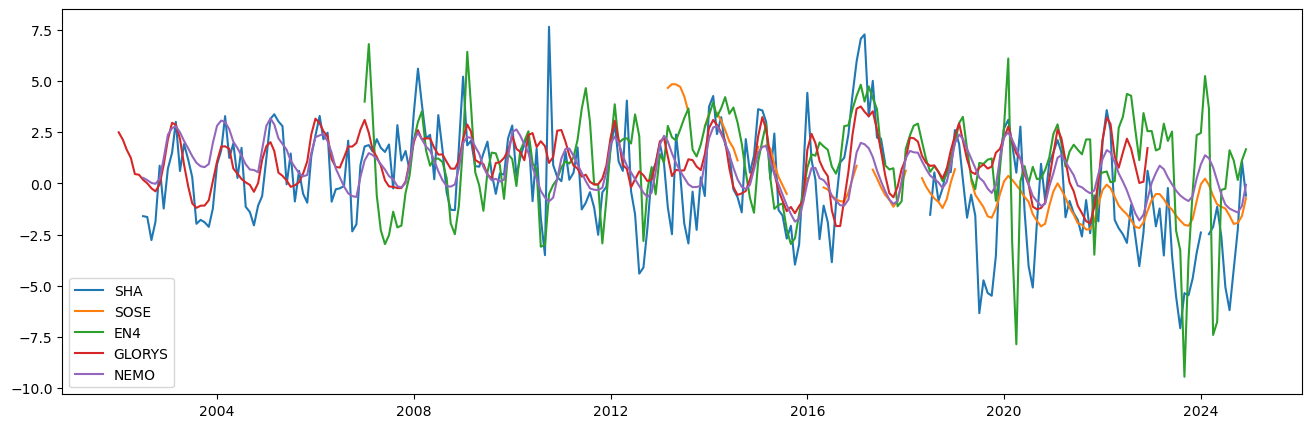

In [60]:
fig, ax = plt.subplots(figsize=(16,5))
ax.plot(offshelf_sha.time,offshelf_sha.mean(['latitude','longitude']),label='SHA')
ax.plot(offshelf_gph_sose.time,offshelf_gph_sose.mean(['XC','YC']),label='SOSE')
ax.plot(offshelf_gph_en4.time,offshelf_gph_en4.mean(['lat','lon']),label='EN4')
ax.plot(offshelf_gph_glorys.time,offshelf_gph_glorys.mean(['latitude','longitude']),label='GLORYS')
ax.plot(offshelf_gph_nemo.time,offshelf_gph_nemo.mean(['x','y']),label='NEMO')
ax.legend()

In [90]:
cdict

{np.int64(2004): array([0.12156863, 0.46666667, 0.70588235, 1.        ]),
 np.int64(2006): array([0.68235294, 0.78039216, 0.90980392, 1.        ]),
 np.int64(2007): array([1.        , 0.49803922, 0.05490196, 1.        ]),
 np.int64(2008): array([1.        , 0.73333333, 0.47058824, 1.        ]),
 np.int64(2009): array([0.17254902, 0.62745098, 0.17254902, 1.        ]),
 np.int64(2010): array([0.59607843, 0.8745098 , 0.54117647, 1.        ]),
 np.int64(2011): array([0.83921569, 0.15294118, 0.15686275, 1.        ]),
 np.int64(2012): array([1.        , 0.59607843, 0.58823529, 1.        ]),
 np.int64(2013): array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 np.int64(2014): array([0.77254902, 0.69019608, 0.83529412, 1.        ]),
 np.int64(2015): array([0.54901961, 0.3372549 , 0.29411765, 1.        ]),
 np.int64(2016): array([0.76862745, 0.61176471, 0.58039216, 1.        ]),
 np.int64(2017): array([0.89019608, 0.46666667, 0.76078431, 1.        ]),
 np.int64(2018): array([0.96862745, 0.

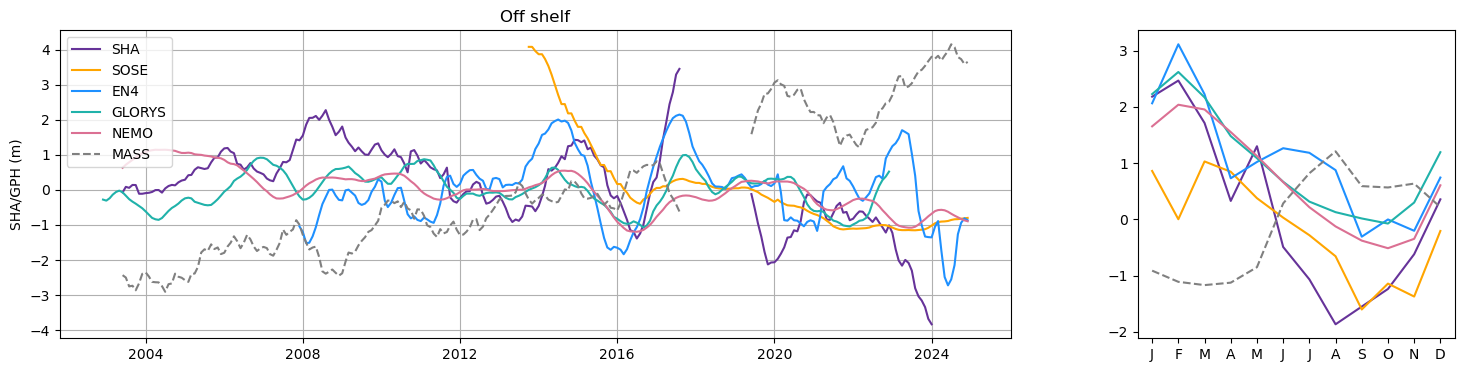

In [115]:
offshelf_sha_clim = offshelf_sha_tmean.groupby('time.month').mean()
offshelf_gph_sose_clim = offshelf_gph_sose_tmean.groupby('time.month').mean()
offshelf_gph_en4_clim = offshelf_gph_en4_tmean.groupby('time.month').mean()
offshelf_gph_glorys_clim = offshelf_gph_glorys_tmean.groupby('time.month').mean()
offshelf_gph_nemo_clim = offshelf_gph_nemo_tmean.groupby('time.month').mean()
offshelf_mass_clim = offshelf_mass_tmean.groupby('time.month').mean()


fig, axs = plt.subplots(1,2,figsize=(18,4),width_ratios=[3,1])
ax=axs[0]
plotvar(ax,(offshelf_sha_tmean.groupby('time.month') - offshelf_sha_clim).rolling({'time':12}).mean(),label='SHA')
plotvar(ax,(offshelf_gph_sose_tmean.groupby('time.month') - offshelf_gph_sose_clim).rolling({'time':12},min_periods=8).mean(),label='SOSE')
plotvar(ax,(offshelf_gph_en4_tmean.groupby('time.month') - offshelf_gph_en4_clim).rolling({'time':12}).mean(),label='EN4')
plotvar(ax,(offshelf_gph_glorys_tmean.groupby('time.month') - offshelf_gph_glorys_clim).rolling({'time':12}).mean(),label='GLORYS')
plotvar(ax,(offshelf_gph_nemo_tmean.groupby('time.month') - offshelf_gph_nemo_clim).rolling({'time':12}).mean(),label='NEMO')
plotvar(ax,(offshelf_mass_tmean.groupby('time.month') - offshelf_mass_clim).rolling({'time':12}).mean(),label='MASS',ls='--')

ax.legend()
ax.grid()
ax.set_ylabel('SHA/GPH (m)')
ax.set_title('Off shelf')

ax=axs[1]
plotcli(ax,offshelf_sha_clim,label='SHA')
plotcli(ax,offshelf_gph_sose_clim,label='SOSE')
plotcli(ax,offshelf_gph_en4_clim,label='EN4')
plotcli(ax,offshelf_gph_glorys_clim,label='GLORYS')
plotcli(ax,offshelf_gph_nemo_clim,label='NEMO')
plotcli(ax,offshelf_mass_clim,label='MASS',ls='--')


In [41]:
cdict

{np.int64(2004): array([0.12156863, 0.46666667, 0.70588235, 1.        ]),
 np.int64(2006): array([0.68235294, 0.78039216, 0.90980392, 1.        ]),
 np.int64(2007): array([1.        , 0.49803922, 0.05490196, 1.        ]),
 np.int64(2008): array([1.        , 0.73333333, 0.47058824, 1.        ]),
 np.int64(2009): array([0.17254902, 0.62745098, 0.17254902, 1.        ]),
 np.int64(2010): array([0.59607843, 0.8745098 , 0.54117647, 1.        ]),
 np.int64(2011): array([0.83921569, 0.15294118, 0.15686275, 1.        ]),
 np.int64(2012): array([1.        , 0.59607843, 0.58823529, 1.        ]),
 np.int64(2013): array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 np.int64(2014): array([0.77254902, 0.69019608, 0.83529412, 1.        ]),
 np.int64(2015): array([0.54901961, 0.3372549 , 0.29411765, 1.        ]),
 np.int64(2016): array([0.76862745, 0.61176471, 0.58039216, 1.        ]),
 np.int64(2017): array([0.89019608, 0.46666667, 0.76078431, 1.        ]),
 np.int64(2018): array([0.96862745, 0.

In [42]:
cdict[np.int64(2002)] = [0.09019608, 0.74509804, 0.81176471, 1.        ]
cdict[np.int64(2003)] = [0.61960784, 0.85490196, 0.89803922, 1.        ]
cdict[np.int64(2005)] = [0.85882353, 0.85882353, 0.55294118, 1.        ]


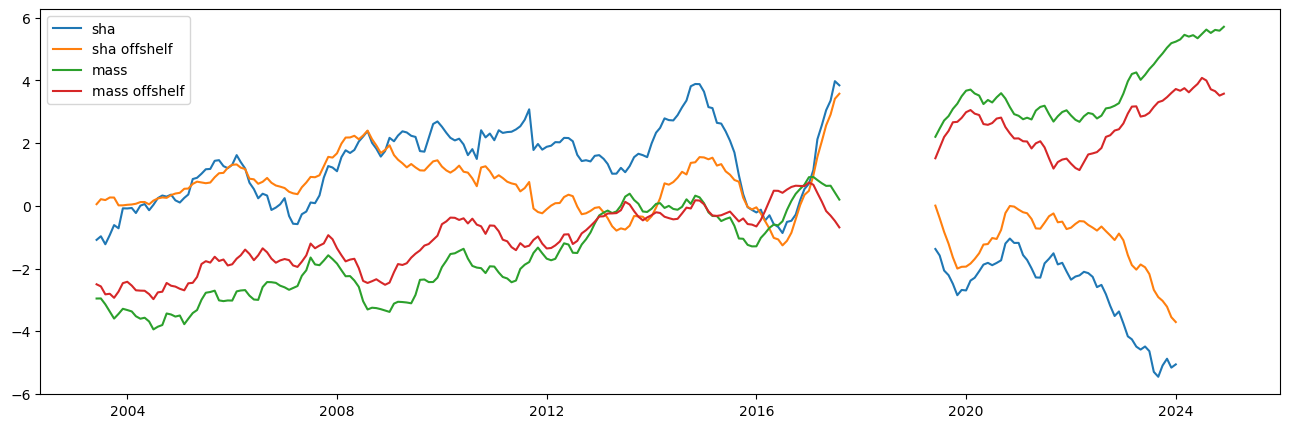

In [67]:
fig,ax = plt.subplots(figsize=(16,5))
ax.plot(shelf_sha.time,shelf_sha.mean(['latitude','longitude']).rolling({'time':12}).mean(),label='sha')
ax.plot(shelf_sha.time,offshelf_sha.mean(['latitude','longitude']).rolling({'time':12}).mean(),label='sha offshelf')
ax.plot(shelf_mass.time,shelf_mass.mean(['latitude','longitude']).rolling({'time':12}).mean(),label='mass')
ax.plot(shelf_mass.time,offshelf_mass.mean(['latitude','longitude']).rolling({'time':12}).mean(),label='mass offshelf')
ax.legend()

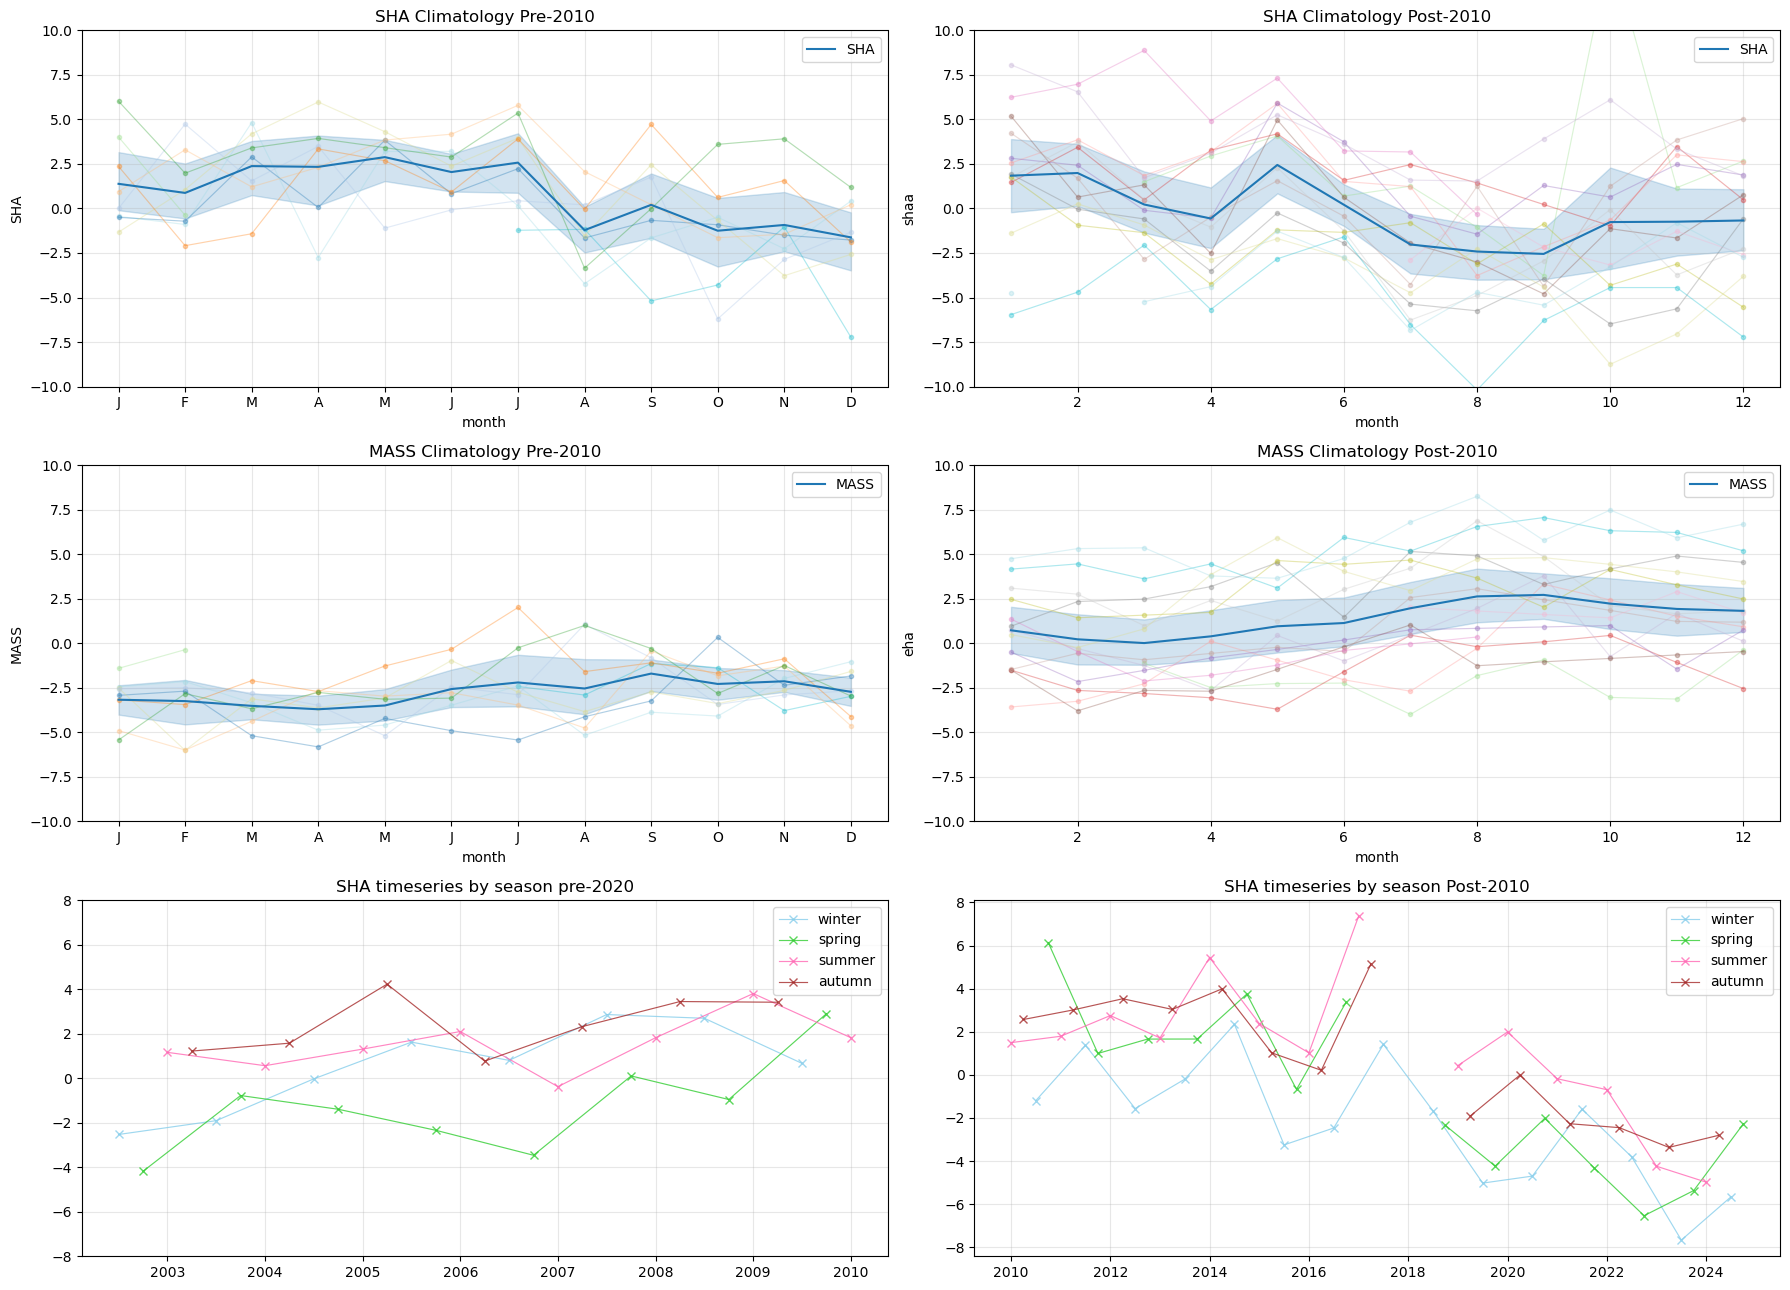

In [55]:
# mnothly variability plot
fig,axs = plt.subplots(3,2,figsize=(18,13))

ax=axs[0] # CLIMATOLOGY sha
bx=axs[1] # CLIMATOLOGY mass
cx=axs[2] # timeseries

sha_pre2010['year'] = sha_pre2010.time.dt.year
sha_pos2010['year'] = sha_pos2010.time.dt.year
for y in np.unique(sha_pre2010.year):
    data = sha_pre2010.where(sha_pre2010.year == y,drop=True)
    data = data.groupby('time.month').mean().broadcast_like(month_values)
    ax[0].plot(data.month,data,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

for y in np.unique(sha_pos2010.year):
    data = sha_pos2010.where(sha_pos2010.year == y,drop=True)
    data = data.groupby('time.month').mean().broadcast_like(month_values)
    ax[1].plot(data.month,data,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

lwe_pre2010['year'] = lwe_pre2010.time.dt.year
lwe_pos2010['year'] = lwe_pos2010.time.dt.year
for y in np.unique(sha_pre2010.year):
    data = lwe_pre2010.where(sha_pre2010.year == y,drop=True)
    data = data.groupby('time.month').mean().broadcast_like(month_values)
    bx[0].plot(data.month,data,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

for y in np.unique(lwe_pos2010.year):
    data = lwe_pos2010.where(sha_pos2010.year == y,drop=True)
    data = data.groupby('time.month').mean().broadcast_like(month_values)
    bx[1].plot(data.month,data,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

ax[0].set_title('SHA Climatology Pre-2010')
ax[1].set_title('SHA Climatology Post-2010')
bx[0].set_title('MASS Climatology Pre-2010')
bx[1].set_title('MASS Climatology Post-2010')

ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)
bx[0].grid(alpha=0.3)
bx[1].grid(alpha=0.3)

ax[0].set_xticks(np.arange(1,13),labels=month_labels)
ax[0].set_ylabel('SHA')
ax[0].set_xlabel(None)
ax[0].set_ylim([-10,10])
ax[1].set_ylim([-10,10])

bx[0].set_xticks(np.arange(1,13),labels=month_labels)
bx[0].set_ylabel('MASS')
bx[0].set_xlabel(None)
bx[0].set_ylim([-10,10])
bx[1].set_ylim([-10,10])
 
seasons_pre = fns.season_split(sha_pre2010)
seasons_pos = fns.season_split(sha_pos2010)

offset = {'summer':0,'autumn':0.25,'winter':0.5,'spring':0.75}
scolor = {'summer':'hotpink','autumn':'brown','winter':'skyblue','spring':'limegreen'}

for s in seasons_pre.keys():
    data = seasons_pre[s].groupby('time.year').mean()
    cx[0].plot(data.year+offset[s],data,marker='x',linestyle='-',alpha=0.8,linewidth=0.85,c=scolor[s],label=s)

    data = seasons_pos[s].groupby('time.year').mean()
    cx[1].plot(data.year+offset[s],data,marker='x',linestyle='-',alpha=0.8,linewidth=0.85,c=scolor[s],label=s)

sha_pre2010['month'] = sha_pre2010.time.dt.month
sha_pos2010['month'] = sha_pos2010.time.dt.month
lwe_pre2010['month'] = lwe_pre2010.time.dt.month
lwe_pos2010['month'] = lwe_pos2010.time.dt.month


sns.lineplot(
    data=sha_pre2010.to_dataframe(),
    x="month", y="shaa", ax=ax[0], label='SHA'
)
sns.lineplot(
    data=sha_pos2010.to_dataframe(),
    x="month", y="shaa", ax=ax[1], label='SHA'
)
sns.lineplot(
    data=lwe_pre2010.to_dataframe(),
    x="month", y="eha", ax=bx[0], label='MASS'
)
sns.lineplot(
    data=lwe_pos2010.to_dataframe(),
    x="month", y="eha", ax=bx[1], label='MASS'
)


cx[0].set_title('SHA timeseries by season pre-2020')
cx[1].set_title('SHA timeseries by season Post-2010')

cx[0].legend(loc='best')
cx[1].legend(loc='best')

cx[0].grid(alpha=0.3)
cx[1].grid(alpha=0.3)

cx[0].set_ylim([-8,8])
cx[0].set_ylim([-8,8])



plt.tight_layout()



In [15]:
n_min = 10

ds_zz_ons = ds_z_ons.mean('pres')
ds_zz_ofs = ds_z_ofs.mean('pres')

mon_mean__ons = ds_zz_ons.resample({'time':'MS'}).mean(skipna=True)
mon_std__ons = ds_zz_ons.resample({'time':'MS'}).std(skipna=True)
mon_count_ons = ds_zz_ons.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean_ons = mon_mean__ons.where(mon_count_ons > n_min, drop=True)
mon_std_ons = mon_std__ons.where(mon_count_ons > n_min, drop=True)

mon_mean__ofs = ds_zz_ofs.resample({'time':'MS'}).mean(skipna=True)
mon_std__ofs = ds_zz_ofs.resample({'time':'MS'}).std()
mon_count_ofs = ds_zz_ofs.resample({'time':'MS'}).count()

# make sure all months used have more than n profiles
mon_mean_ofs = mon_mean__ofs.where(mon_count_ofs > n_min, drop=True)
mon_std_ofs = mon_std__ofs.where(mon_count_ofs > n_min, drop=True)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py

In [16]:
cli_count_ons = mon_mean_ons.groupby('time.month').count()

cli_mean_ons = mon_mean_ons.groupby('time.month').mean()
cli_std_ons = mon_mean_ons.groupby('time.month').std()

cli_mean_ons = cli_mean_ons.where(cli_count_ons.temp > 1,drop=True)
cli_std_ons = cli_std_ons.where(cli_count_ons.temp >1,drop=True)

cli_count_ofs = mon_mean_ofs.groupby('time.month').count()

cli_mean_ofs = mon_mean_ofs.groupby('time.month').mean()
cli_std_ofs = mon_mean_ofs.groupby('time.month').std()

cli_mean_ofs = cli_mean_ofs.where(cli_count_ofs.temp > 1,drop=True)
cli_std_ofs = cli_std_ofs.where(cli_count_ofs.temp >1,drop=True)



/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/

In [17]:
df_ons=mon_mean_ons.groupby('time.month').where(cli_count_ons.temp > 1).to_dataframe()
df_ofs=mon_mean_ofs.groupby('time.month').where(cli_count_ofs.temp > 1).to_dataframe()


In [18]:
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
month_values = xr.DataArray(np.arange(1,13),coords={'month':np.arange(1,13)})

In [54]:
dfonshelf = ds_z_ons.drop_dims('pres').drop_vars(['mld']).to_dataframe()
dfonshelf['season'] = [fns.get_season(m) for m in dfonshelf.month]

dfoffshelf = ds_z_ofs.drop_dims('pres').drop_vars(['mld']).to_dataframe()
dfoffshelf['season'] = [fns.get_season(m) for m in dfoffshelf.month]

In [55]:
dfonshelf=dfonshelf.dropna()
dfonshelf['shaa']=dfonshelf.sha_interp - dfonshelf.sha_interp.mean()
dfonshelf['gpha']=dfonshelf.gph - dfonshelf.gph.mean()

dfoffshelf=dfoffshelf.dropna()
dfoffshelf['shaa']=dfoffshelf.sha_interp - dfoffshelf.sha_interp.mean()
dfoffshelf['gpha']=dfoffshelf.gph - dfoffshelf.gph.mean()


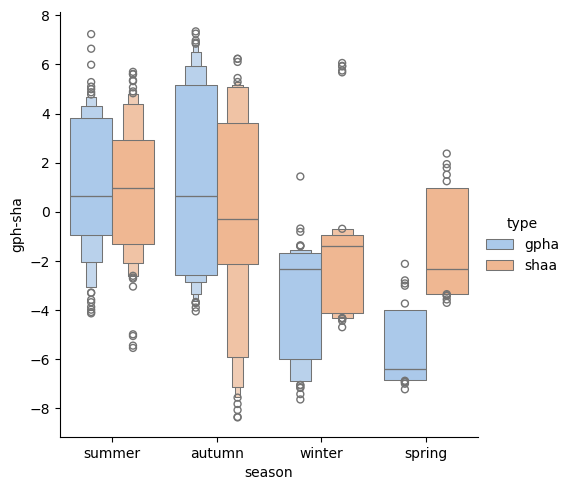

In [62]:
dfsns=dfonshelf.reset_index().melt(
    value_vars=['gpha', 'shaa'],
    var_name='type',
    value_name='gph-sha',
    id_vars=['season']
)

sns.catplot(data=dfsns,x='season',y='gph-sha',hue='type',order=['summer','autumn','winter','spring'],kind='boxen',palette='pastel')

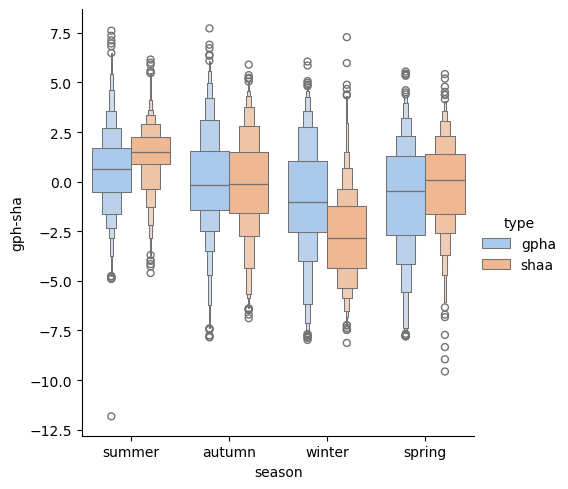

In [63]:
dfsns=dfoffshelf.reset_index().melt(
    value_vars=['gpha', 'shaa'],
    var_name='type',
    value_name='gph-sha',
    id_vars=['season']
)

sns.catplot(data=dfsns,x='season',y='gph-sha',hue='type',order=['summer','autumn','winter','spring'],kind='boxen',palette='pastel')

In [23]:
def yearly_climatology(ax,y,datamean,datastd):
    data = datamean.where(datamean.year==y,drop=True)
    dats = datastd.where(datamean.year==y,drop=True)

    if not len(data.time) == 0:
        clim = data.groupby('time.month').mean().broadcast_like(month_values)
        clis = dats.groupby('time.month').mean().broadcast_like(month_values)

        ax.errorbar(clim.month,clim.gph,yerr=clis.gph,marker='o',markersize=3,alpha=0.35,linewidth=0.85,c=cdict[y])

def histogram(bx,y,mon_count,mon_mean_,bottom):
    year_count = mon_count.temp.where(mon_mean_.year==y,drop=True)
    if len(year_count) > 0:
        year_count = np.nan_to_num(year_count.groupby('time.month').mean().broadcast_like(month_values))
        if len(bx.containers) > 0:
            bx.bar(month_values, year_count, bottom = bottom,color=cdict[y],label=str(y))
            bottom = bottom + year_count
        else:
            bx.bar(month_values, year_count,color=cdict[y],label=str(y))
            bottom = year_count.copy()
    return bottom

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension month because variable month is not a coordinate. To create an index for month, please first call `.set_coords('month')` on

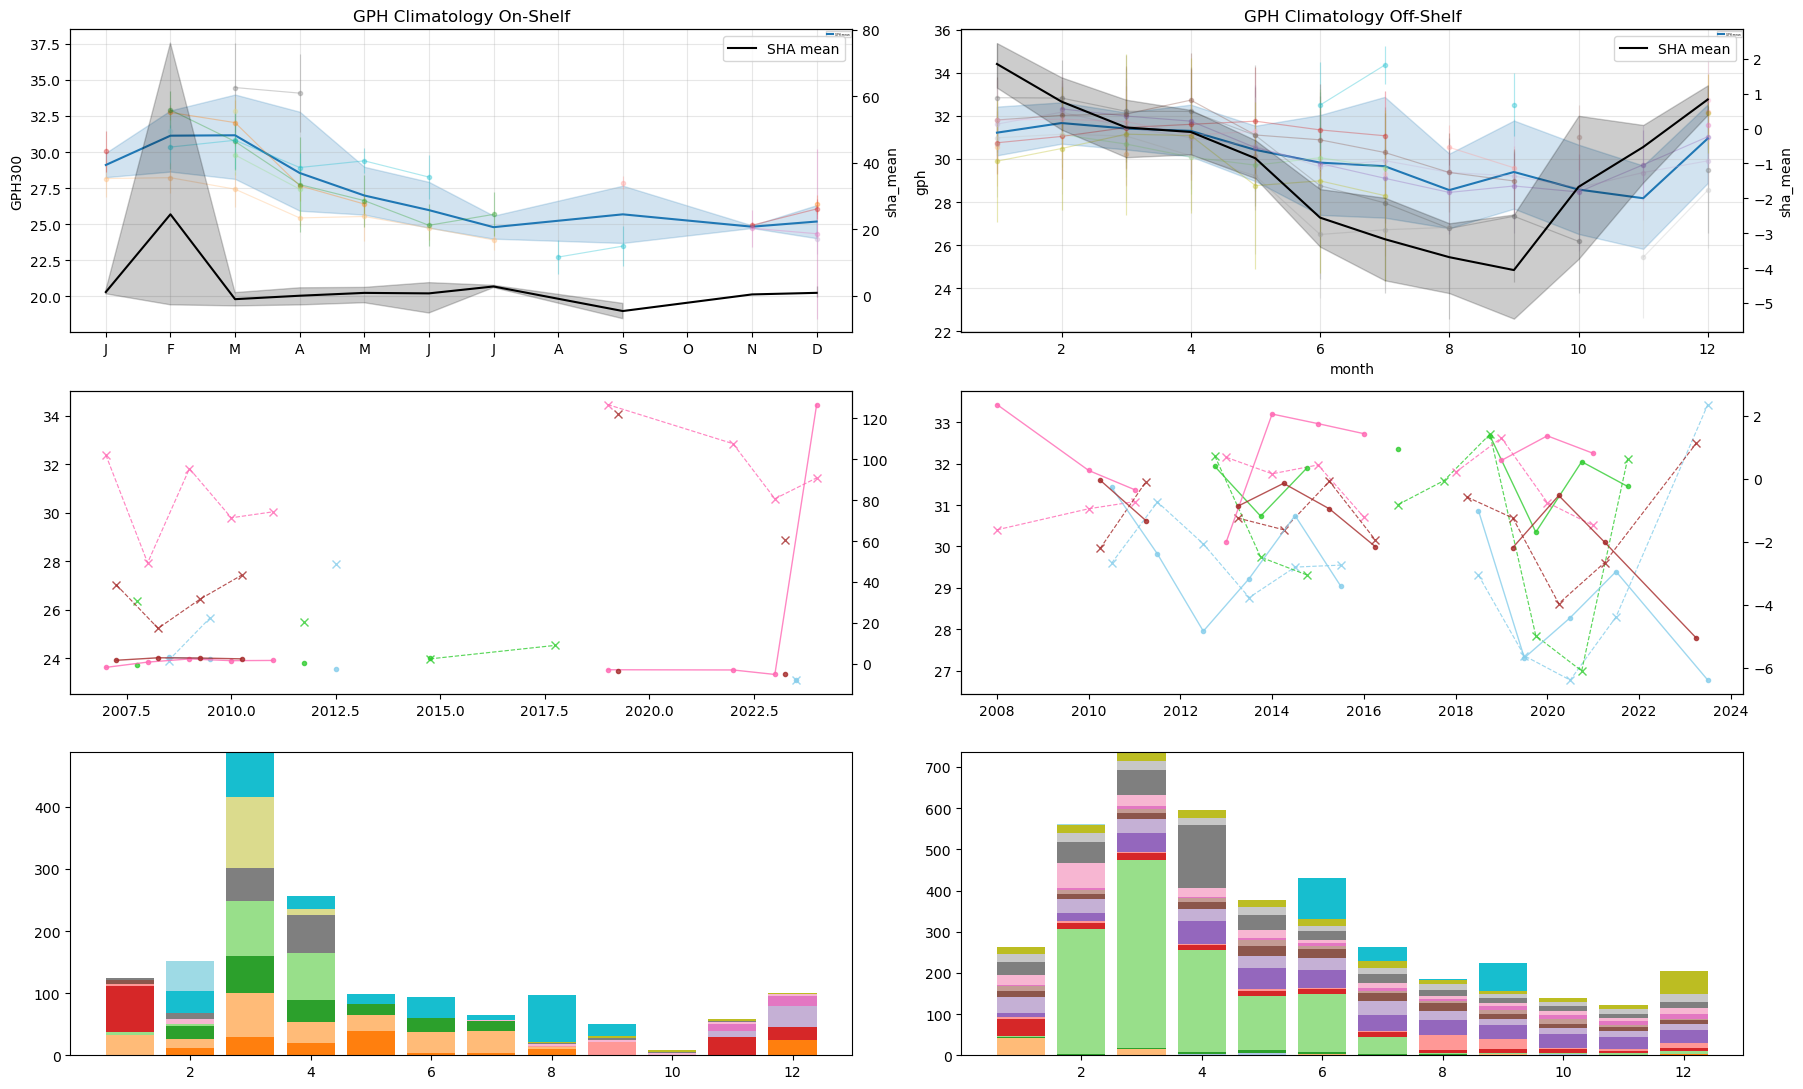

In [20]:
# mnothly variability plot
fig,axs = plt.subplots(3,2,figsize=(18,11))

ax=axs[0]
cx=axs[1]
bx=axs[2]

bot0 = None
bot1 = None

for y in [int(k) for k in cdict.keys()]:
    yearly_climatology(ax[0],y,mon_mean_ons,mon_std_ons)
    yearly_climatology(ax[1],y,mon_mean_ofs,mon_std_ofs)

    bot0=histogram(bx[0],y,mon_count_ons,mon_mean__ons,bot0)
    bot1=histogram(bx[1],y,mon_count_ofs,mon_mean__ofs,bot1)
    

seasons_ons = fns.season_split(mon_mean_ons)
seasons_ofs = fns.season_split(mon_mean_ofs)

offset = {'summer':0,'autumn':0.25,'winter':0.5,'spring':0.75}
scolor = {'summer':'hotpink','autumn':'brown','winter':'skyblue','spring':'limegreen'}

shax0=cx[0].twinx()
shax1=cx[1].twinx()
for s in seasons_ons.keys():
    data = seasons_ons[s].groupby('time.year').mean()
    cx[0].plot(data.year+offset[s],data.gph,marker='x',linestyle='--',alpha=0.8,linewidth=0.85,c=scolor[s],label=s)
    shax0.plot(data.year+offset[s],data.sha_mean,marker='.',linestyle='-',alpha=0.8,linewidth=1,c=scolor[s],label=s)

    data = seasons_ofs[s].groupby('time.year').mean()
    cx[1].plot(data.year+offset[s],data.gph,marker='x',linestyle='--',alpha=0.8,linewidth=0.85,c=scolor[s],label=s)
    shax1.plot(data.year+offset[s],data.sha_mean,marker='.',linestyle='-',alpha=0.8,linewidth=1,c=scolor[s],label=s)


sns.lineplot(
    data=df_ons,
    x="month", y="gph", errorbar=("pi",90), ax=ax[0], label='GPH mean'
)
sns.lineplot(
    data=df_ons,
    x="month", y="sha_mean", ax=ax[0].twinx(), label='SHA mean', color='k'
)
sns.lineplot(
    data=df_ofs,
    x="month", y="gph", errorbar=("pi",90), ax=ax[1], label='GPH mean'
)
sns.lineplot(
    data=df_ofs,
    x="month", y="sha_mean", ax=ax[1].twinx(), label='SHA mean', color='k'

)

ax[0].set_title('GPH Climatology On-Shelf')
ax[1].set_title('GPH Climatology Off-Shelf')

ax[0].legend(loc='best',fontsize=2)
ax[1].legend(loc='best',fontsize=2)


ax[0].grid(alpha=0.3)
ax[1].grid(alpha=0.3)

ax[0].set_xticks(np.arange(1,13),labels=month_labels)
ax[0].set_ylabel('GPH300')
ax[0].set_xlabel(None)


# cx.grid(alpha=0.3)
# cx.set_xticks(np.arange(1,13),labels=month_labels)
# cx.set_ylabel('Salinity')
# cx.set_xlabel(None)
# cx.legend()

plt.tight_layout()



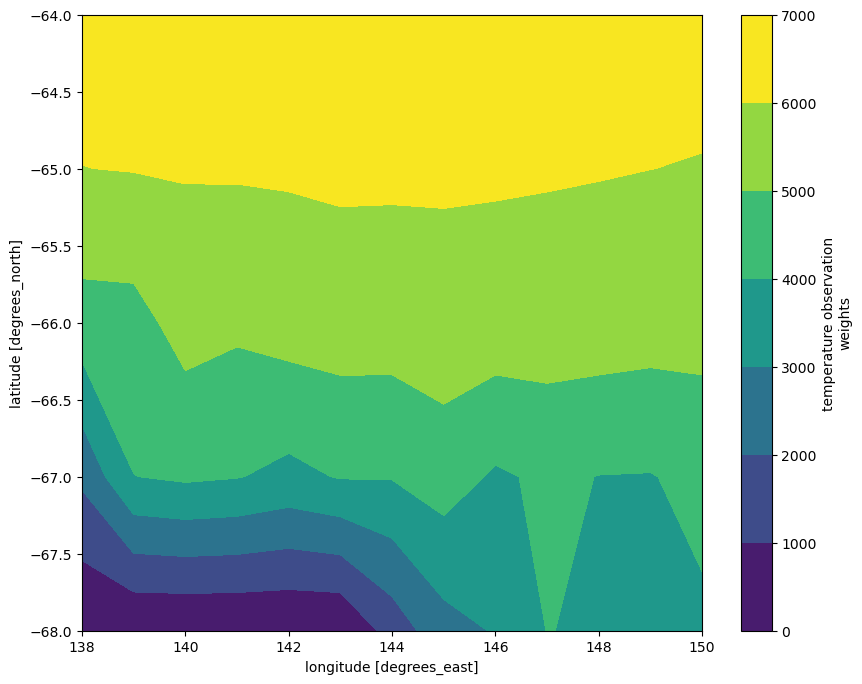

In [28]:
fig,ax = plt.subplots(figsize=(10,8))
en4.temperature_observation_weights.sum(['time','depth']).plot.contourf(ax=ax)


In [ ]:
en4

<xarray.Dataset> Size: 38MB
Dimensions:                          (depth: 42, lat: 5, lon: 13, time: 216,
                                      bnds: 2)
Coordinates:
  * depth                            (depth) float32 168B 5.022 ... 5.35e+03
  * lat                              (lat) float32 20B -68.0 -67.0 ... -64.0
  * lon                              (lon) float32 52B 138.0 139.0 ... 150.0
  * time                             (time) datetime64[ns] 2kB 2007-01-16T12:...
Dimensions without coordinates: bnds
Data variables: (12/15)
    temperature                      (time, depth, lat, lon) float64 5MB ...
    salinity                         (time, depth, lat, lon) float64 5MB ...
    temperature_uncertainty          (time, depth, lat, lon) float64 5MB ...
    salinity_uncertainty             (time, depth, lat, lon) float64 5MB ...
    temperature_observation_weights  (time, depth, lat, lon) float32 2MB nan ...
    salinity_observation_weights     (time, depth, lat, lon) float32 2MB ...
    ...                               ...
    year                             (time) int64 2kB 2007 2007 ... 2024 2024
    pres                             (depth) float64 336B nan nan ... nan nan
    asal                             (time, depth, lat, lon) float64 5MB nan ...
    ctemp                            (time, depth, lat, lon) float64 5MB nan ...
    rho                              (time, depth, lat, lon) float64 5MB nan ...
    gph                              (time, lat, lon) float64 112kB nan ... nan
Attributes: (12/22)
    Conventions:            CF-1.0
    title:                  Temperature and salinity analysis
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    references:             Website and paper: https://www.metoffice.gov.uk/h...
    institution:            UK Met Office
    contact:                Rachel Killick - rachel.killick@metoffice.gov.uk
    ...                     ...
    southernmost_latitude:  -90.5
    northernmost_latitude:  89.5
    westernmost_longitude:  0.5
    easternmost_longitude:  362.5
    file_quality_index:     0
    licence:                EN4 is distributed under the Non Commercial Gover...

In [ ]:
en4['pres']=gsw.conversions.p_from_z(en4.depth,en4.lat.mean())
en4['asal']=gsw.conversions.SA_from_SP(en4.salinity,en4.pres,en4.lon,en4.lat)
en4['ctemp']=gsw.conversions.CT_from_t(en4.asal,en4.temperature,en4.pres)
en4['rho']=gsw.density.rho(en4.asal,en4.ctemp,en4.pres)

# calculate specific volume for each profile/level
vs = (1/en4.rho - 1/gsw.density.rho(35,0,600))/9.82#ds[pres]))/9.82
vs = vs.assign_coords({'PRES_Pa': en4.pres*10000})

# integrate vs to get gpha for each profile
en4['gph'] = vs.groupby('time').map(lambda x: fns.integrate_na(x))

NameError: name 'en4' is not defined

/tmp/ipykernel_1290419/839765754.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()],label=str(y.item())))
/tmp/ipykernel_1290419/839765754.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ims.append(ax.scatter(data.psal,data.temp,alpha=0.05,c=cdict[y.item()],label=str(y.item())))
/tmp/ipykernel_1290419/839765754.py:8: UserWarning: *c* argument looks l

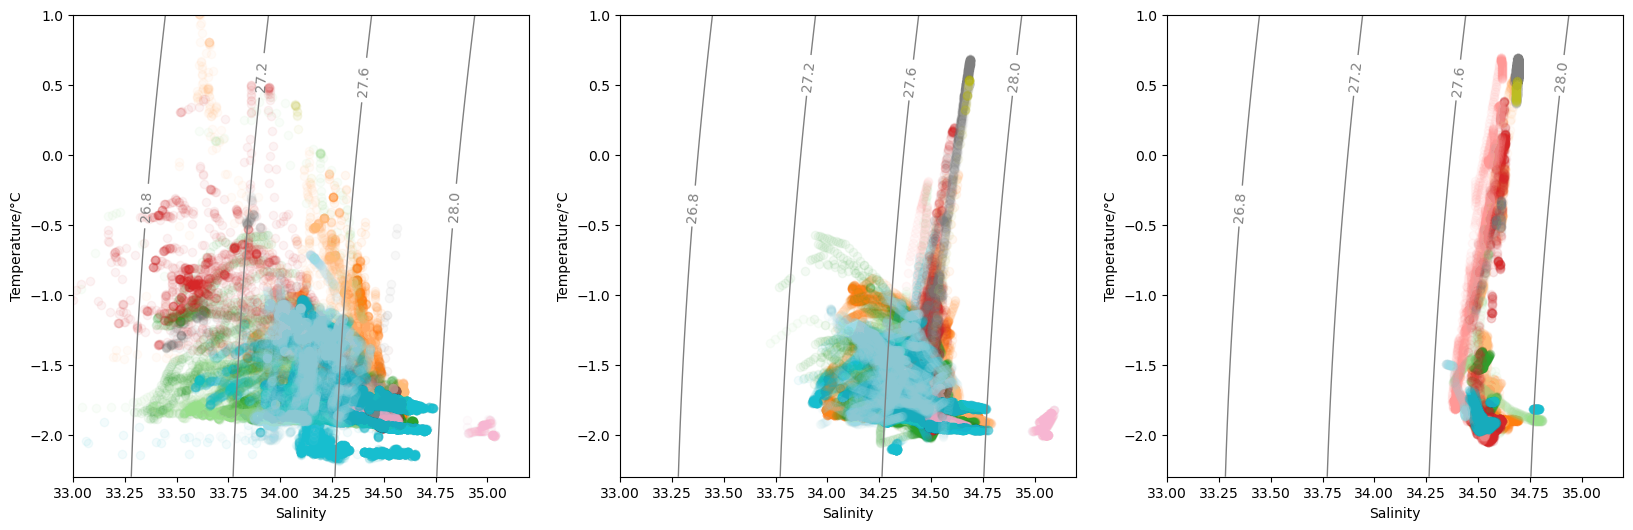

In [ ]:
# mnothly variability plot
fig,axs = plt.subplots(3,1,figsize=(10,11))
mon_year = mon_mean.groupby('time.year').mean()
moc_year = mon_count.where(mon_count.temp).groupby('time.year').count()


ax=axs[0]
cx=axs[1]
bx=axs[2]

for y_da in moc_year.year:
    y = y_da.item()
    data = mon_mean.where(mon_mean.year==y,drop=True)
    dats = mon_std.where(mon_mean.year==y,drop=True)

    if not len(data.time) ==0:
        clim = data.groupby('time.month').mean().broadcast_like(month_values)
        clis = dats.groupby('time.month').mean().broadcast_like(month_values)

        ax.errorbar(clim.month,clim.gph,yerr=clis.gph,marker='o',alpha=0.5,linewidth=0.85,c=cdict[y])
        
cx.scatter(mon_year.year,mon_year.gph,marker='x',alpha=0.8,linewidth=0.85,c='steelblue')

    # histogram
    # year_count = mon_count.temp.where(mon_mean_.year==y,drop=True)
    # if len(year_count) > 0:
    #     year_count = np.nan_to_num(year_count.groupby('time.month').mean().broadcast_like(month_values))
    #     if y > 2007:
    #         bx.bar(month_values, year_count, bottom = bottom,color=cdict[y],label=str(y))
    #         bottom = bottom + year_count
    #     else:
    #         bx.bar(month_values, year_count,color=cdict[y],label=str(y))
    #         bottom = year_count.copy()
        

ax.legend(loc='best',fontsize=2)
# bx.legend(ncol=7,fontsize='small')
# bx.set_ylabel('Number of Profiles')
# bx.set_xticks(np.arange(1,13),labels=month_labels)


sns.lineplot(
    data=df,
    x="month", y="gph", errorbar=("pi",90), ax=ax, 
)

        
# sns.lineplot(
#     data=df,
#     x="month", y="psal", errorbar=("pi",90), ax=cx
# )



ax.grid(alpha=0.3)
ax.set_xticks(np.arange(1,13),labels=month_labels)
ax.set_ylabel('GPH')
ax.set_xlabel(None)
ax.legend()

# cx.grid(alpha=0.3)
# cx.set_xticks(np.arange(1,13),labels=month_labels)
# cx.set_ylabel('Salinity')
# cx.set_xlabel(None)
# cx.legend()

plt.tight_layout()

